In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

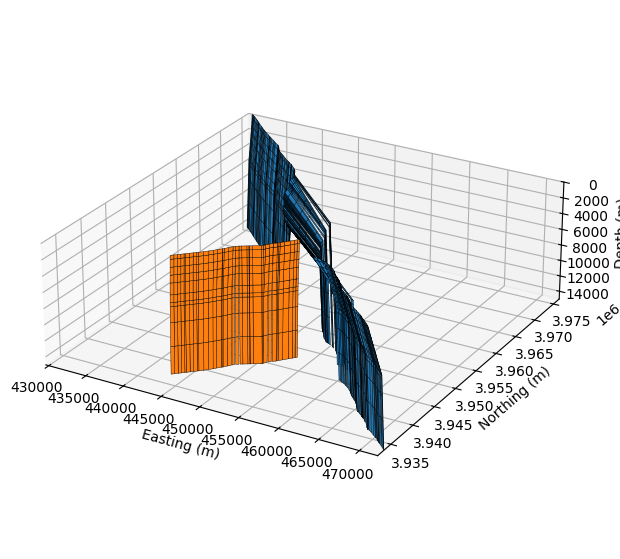

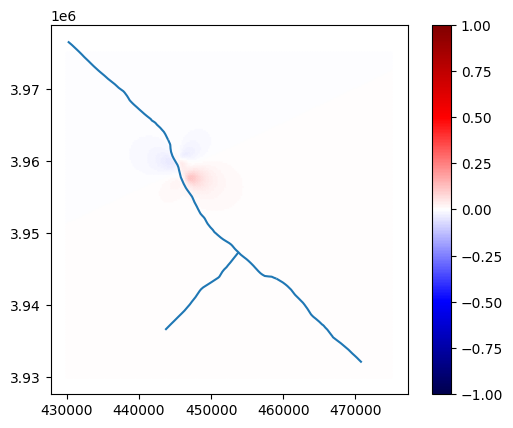

In [3]:
from codes import Fault3d
import cmcrameri.cm as cmc

filepath = "/Users/hintont/Dev/projects/ridgecrest/data/fault/little_lake_trace_multi.shp"
vertical_discretisation = [0, 500, 1500, 2500, 3500, 5000, 6500, 8500, 11500, 15000]
geom = {
    1: dict(dip_sh=85, dip_dp=88, kink_z=6000, slip_sign=-1),  # ELLF north  (dip_az 225, SW)
    2: dict(dip_sh=55, dip_dp=88, kink_z=6000, slip_sign=-1),  # ELLF central(dip_az  45, NE)
    3: dict(dip_sh=75, dip_dp=88, kink_z=6000, slip_sign=-1),  # ELLF south  (dip_az  45, NE)
    4: dict(dip_sh=85, dip_dp=88, kink_z=6000, slip_sign=+1),  # SLLF        (dip_az 315, NW)
}

fault = Fault3d(trace_shp_filepath=filepath)
fault = fault.build_patches(vertical_discretisation, patch_length=3000., geom=geom)

xs, ys = np.meshgrid(
    np.linspace(4.3e5, 4.75e5, 200),
    np.linspace(3.93e6, 3.975e6, 200)
)
xys = np.vstack((xs.flatten(), ys.flatten()))
fault = fault.compute_greens_functions(xys)

# 3D visual confirmation of the dipping fault geometry
fault.plot_fault3d(color_by="fault")

# Example: surface GF (east comp.) for one cell's strike-slip
ax = fault.trace.plot()
sar = ax.scatter(xs, ys, c=fault.gfs[0, 10, 0, :], s=.3, zorder=.5, cmap="seismic", vmin=-1., vmax=1.)
plt.colorbar(sar)

Importing GRD: /Users/hintont/Dev/projects/Ridgecrest/data/insar/D071_20190704-0716/unwrapped.grd
  Loaded 6795141 pixels
  After bbox selection: 1372750 pixels
Computing spatial covariance...
  Sampling 5524 pixels from 1104870
  Sill=0.000289, Sigma=0.020253, Lambda=13168.6 m


(<Figure size 700x600 with 2 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

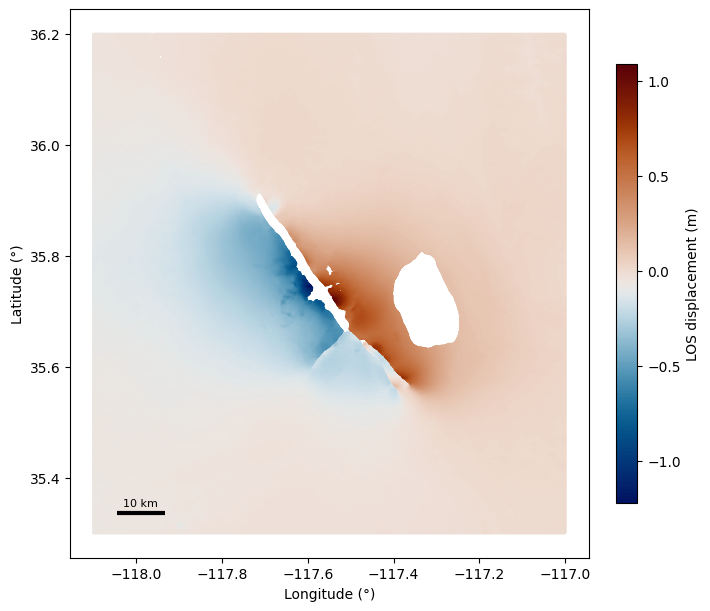

In [ ]:
from codes import InSAR
dir = "/Users/hintont/Dev/projects/Ridgecrest/data/insar/A064_20190704-0710/"
dir = "/Users/hintont/Dev/projects/Ridgecrest/data/insar/D071_20190704-0716/"

unw=dir+"unwrapped.grd"
e=dir+"east.grd"
n=dir+"north.grd"
u=dir+"up.grd"

bbox = (-118.1, -117.0 ,35.3, 36.2)
cov_mask_out = [ -117.88,-117.3,35.53,35.9]

insar = InSAR(unw_filepath=unw, los_filepaths=(e,n,u), utm_zone=11, bbox=bbox)
insar = insar.compute_covariance(mask_box=cov_mask_out, frac=0.005, distmax=25000)
insar = insar.downsample(fault, char_dist=-5000., expo_dist=1.1, min_size=500, start_size=16000, scaler=0.7, reject_distance=1000. )
insar = insar.build_Cd()
insar = insar.compute_greens_functions(fault)
insar.plot_covariance()
insar.plot()

Importing GNSS: /Users/hintont/Dev/projects/ridgecrest/data/gnss/unr_gps_offsets_full.txt
  Loaded 481 stations
  After distance filter (100.0 km): 48 stations
  Built diagonal Cd (96 x 96)
  Green's functions shape: (2, 252, 96)


(<Figure size 700x600 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

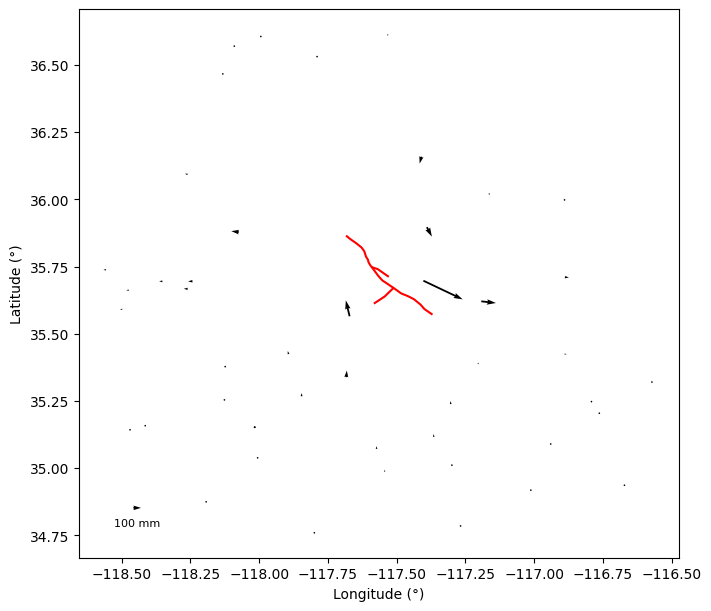

In [18]:
from codes import GNSS

gnss_path = "/Users/hintont/Dev/projects/ridgecrest/data/gnss/unr_gps_offsets_full.txt"
gnss = GNSS()
gnss = gnss.import_data(filepath=gnss_path, utm_zone=11, fault=fault, max_dist=100000)
gnss = gnss.compute_covariance(sde_scale_factor=30.)
gnss = gnss.compute_greens_functions(fault)
gnss.plot(fault=fault)

In [ ]:
from codes import InversionManager

inversion = InversionManager()
inversion = inversion.set_datasets({"ascending-insar": insar, "gnss": gnss}, solve_for_ramp=["ascending-insar"]) # this should also assemble covariance matrix and greens function matrix
inversion.save_to_hdf5("/Users/hintont/Dev/projects/ridgecrest/data/inversion/") # save to h5 files in directory, under names "data", "covariance", and "gf"
# fault.save_patch_areas("/Users/hintont/Dev/projects/ridgecrest/data/inversion/patch_areas.h5")
inversion = inversion.run(bounds=(0., 8.)) # run a simple least squares inversion and store the result. Don't worry about plotting the result for now, can do that later.
inversion.summary()
inversion.plot_map(fault=fault, vlim=(-.8, .8), gnss_scale=.5)
n_cells = len(fault.cells)
fault.slips = np.array(inversion.m[:n_cells])   # strike-slip block (first n_cells of m)
fault.plot_slip(vmin=0., vmax=5., cmap=cmc.lajolla_r)   # ELLF / SLLF on separate axes
inversion.plot_residuals(fault=fault, vlim=(-.8, .8), gnss_scale=.5)

import copy
altar_inversion = copy.deepcopy(inversion)

<HDF5 file "step_final.h5" (mode r)>
<HDF5 group "/ParameterSets" (3 members)>


<Axes: xlabel='Along-strike distance', ylabel='Depth'>

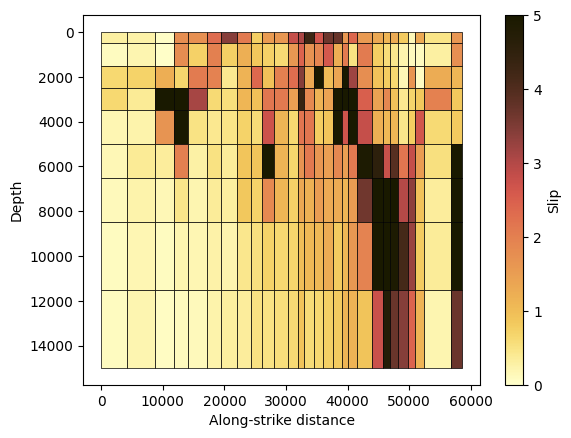

In [23]:
import h5py
import numpy as np
import copy
import cmcrameri.cm as cmc

altar_fault = copy.deepcopy(fault)

with h5py.File("/Users/hintont/Dev/projects/ridgecrest/results/inversion_results/in16/outputs/step_final.h5", "r") as f:
    print(f)
    print(f["ParameterSets"])
    strikeslips = f["ParameterSets"]["strikeslip"][:]

medians = np.median(strikeslips, axis=0)
sigmas = np.std(strikeslips, axis=0)

altar_fault.slips = medians
# altar_fault.sigmas = sigmas

altar_fault.plot_slip(vmin=0., vmax=5., cmap=cmc.lajolla_r)


    # with h5py.File(f"../results/inversion_results/{dirname}/outputs/{filename}", "r") as f:
    #     slips[i] = -soln(f["ParameterSets"]["strikeslipmain"], method="median")
    #     sigmas[i] = np.std(f["ParameterSets"]["strikeslipmain"], axis=0)

(array([41., 42., 44., 36., 28., 14., 10., 10., 10., 17.]),
 array([0.04193335, 0.29606669, 0.55020003, 0.80433337, 1.05846671,
        1.31260005, 1.5667334 , 1.82086674, 2.07500008, 2.32913342,
        2.58326676]),
 <BarContainer object of 10 artists>)

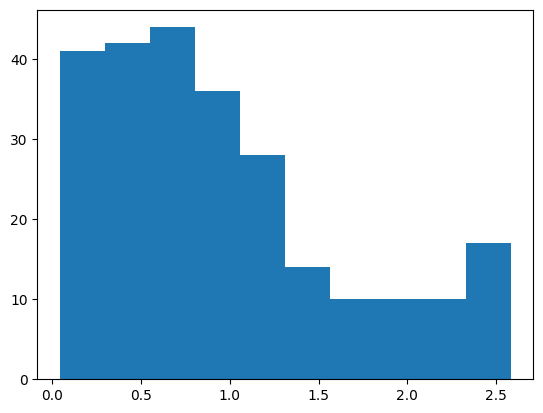

In [22]:
plt.hist(altar_fault.sigmas)

In [ ]:
# Validation: a long vertical strike-slip patch must match the 2D screw-dislocation
# analytic solution at its mid-section (the one rigorous Okada check available).
from codes import Fault3d, Patch, Cell, TwoDHomogeneousForwardModel

patch = Patch(-100000., 0., 10000., 100000., 0., 0., dip=np.pi/2, slip_sign=1)
testfault = Fault3d()
cell = Cell(fault="test", slip_sign=1, x_along=0., width=2e5, z_top=0., z_bot=1e4)
cell.patches = [patch]
testfault.cells = {(0, 0): cell}
testfault.slips = np.zeros(1)

xs = np.zeros(1000)
ys = np.linspace(-10000., 10000., 1000)
pts = np.vstack((xs, ys))
testfault = testfault.compute_greens_functions(pts)

twodmodel = TwoDHomogeneousForwardModel().run(ys)

plt.plot(ys, testfault.gfs[0, 0, 0, :], label="okada 3d")
plt.plot(ys, twodmodel.sol, label="two d model")
plt.legend()